# 01. Source exploration: what did the archive actually contain?

We did not begin with a clean session table. We began with **12,284 component-level weighing events** in 11 CSV files and had to establish what a session meant, keep two populations apart, investigate a timezone discrepancy, cope with schema drift and unstable component names, and decide what the evidence could legitimately support.

**Labels.** "registered-export population" and "non-registered-export population" are **inherited from source filenames**. The public documentation reviewed for this project does not define them, so they are population labels only, not customer-registration status.

Every table below is loaded from `outputs/phase2/` (written by the exploration scripts `phase2_*.py`). Nothing here is cleaned or modified; nothing is dropped.

In [1]:
import pandas as pd
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
P = "../outputs/phase2/"
schema = pd.read_csv(P + "schema_drift_by_file.csv")
pop = pd.read_csv(P + "population_profile.csv", index_col=0)
tz = pd.read_csv(P + "timezone_validation_by_file.csv")
scan = pd.read_csv(P + "timezone_offset_scan.csv")
cross = pd.read_csv(P + "crossover_session_event_comparison.csv")
m4 = pd.read_csv(P + "m4_definition_sensitivity.csv")
day = pd.read_csv(P + "daily_volume_by_population.csv")
comp = pd.read_csv(P + "registered_export_daily_composition.csv")
kpi = pd.read_csv(P + "kpi_sensitivity_preview.csv")
issues = pd.read_csv("../outputs/validation/validation_issues.csv")
print("events in the archive: 12,284 | files:", len(schema), "| session IDs: 3,343")

events in the archive: 12,284 | files: 11 | session IDs: 3,343


## 1. Schema drift
Seven of eleven files have no `weighting_type` column, two timestamp formats appear (decided per **column**, because one file mixes them), and file order is not chronological. Pipeline consequence: parse by header name, sort by parsed time, never trust row order.

In [2]:
print(schema[["file", "rows", "columns_named", "has_weighting_type", "ts_format_weighing", "ts_format_identification"]].to_string(index=False))

                                    file  rows  columns_named  has_weighting_type  ts_format_weighing ts_format_identification
non_registered_2020-10-05_2020-10-18.csv  1313              8                True 9999-99-99 99:99:99      9999-99-99 99:99:99
non_registered_2020-10-19_2020-10-25.csv   698              8                True 9999-99-99 99:99:99      9999-99-99 99:99:99
non_registered_2020-10-25_2020-10-31.csv   721              7               False 9999-99-99 99:99:99      9999-99-99 99:99:99
non_registered_2020-11-02_2020-11-08.csv   600              7               False 9999-99-99 99:99:99      9999-99-99 99:99:99
non_registered_2020-11-09_2020-11-15.csv   580              7               False 9999-99-99 99:99:99      9999.99.99 99:99:99
    registered_2020-10-19_2020-10-25.csv  1352              8                True 9999-99-99 99:99:99      9999-99-99 99:99:99
    registered_2020-10-25_2020-10-31.csv  1396              7               False 9999-99-99 99:99:99      9999

## 2. The two populations behave differently
Crossover sessions are excluded from both columns. A 4 g tenth percentile is not a plausible plate, so the non-registered-export population is a diagnostic, not a KPI source. Note also the daily volume row: 2 to 107 sessions per day in one export, 36 to 75 in the other.

In [3]:
print(pop.drop(columns="note").round(2).to_string())

                            non_registered_export  registered_export
sessions                                  1644.00            1697.00
events                                    3900.00            8360.00
events_per_session_mean                      2.37               4.93
events_per_session_median                    2.00               5.00
single_event_sessions                      620.00              17.00
single_event_pct                            37.71               1.00
with_hot_scale_pct                          74.94              97.17
weight_p10                                   4.00             314.00
weight_median                              192.00             499.00
weight_p90                                 855.40            1039.60
weight_max                                2640.00            3427.00
under_50g_pct                               28.41               0.41
distinct_components_median                   2.00               5.00
span_s_median                     

## 3. Timezone: evidence, not assumption
One file's first weighing of the day is at 07:30, against 10:30 in every other file. We scanned offsets from -6 h to +6 h. **+3 h is the strongest-supported normalisation decision based on cross-export consistency evidence; the source metadata does not explicitly confirm the timezone.**

In [4]:
print(scan.round(3).T.to_string(header=False))
print()
print(tz[["file", "median_first_event_hour_raw", "median_first_event_hour_after_rule", "T07_suspect_raw", "T07_suspect_after_rule"]].to_string(index=False))

offset_h                                     -6.0 -5.0 -4.0 -3.0 -2.0 -1.0  0.000  1.000  2.000  3.000  4.000  5.000  6.00
L1_distance_to_other_registered_export_files  2.0  2.0  2.0  2.0  2.0  2.0  1.994  1.536  1.029  0.046  1.064  1.575  1.99

                                    file  median_first_event_hour_raw  median_first_event_hour_after_rule  T07_suspect_raw  T07_suspect_after_rule
non_registered_2020-10-05_2020-10-18.csv                        10.52                               10.52            False                   False
non_registered_2020-10-19_2020-10-25.csv                        10.53                               10.53            False                   False
non_registered_2020-10-25_2020-10-31.csv                        10.48                               10.48            False                   False
non_registered_2020-11-02_2020-11-08.csv                        10.52                               10.52            False                   False
non_registered_202

## 4. The two crossover sessions
`session2266` is an exact duplicate across exports (0 s apart). `session3222` differs by exactly 10,800 s and 2 of 6 component names differ. Both are quarantined until the source owner says which record is authoritative.

In [5]:
print(cross[["session_id", "scale_id", "weight_g", "name_registered_export", "name_non_registered_export", "dt_s(non_reg - reg)"]].to_string(index=False))

 session_id              scale_id  weight_g name_registered_export name_non_registered_export  dt_s(non_reg - reg)
session2266       vege2-salaatti1        55         American salad             American salad                  0.0
session2266       vege2-salaatti2        80          Grated carrot              Grated carrot                  0.0
session2266       vege2-salaatti3        64                   Papu                       Papu                  0.0
session2266       vege2-salaatti4        70               Beetroot                   Beetroot                  0.0
session2266         vege2-lammin2       192         vegan Stir fry             vegan Stir fry                  0.0
session3222 koti2-vasen-salaatti1       623         American salad             American salad              10800.0
session3222 koti2-vasen-salaatti1         6         American salad             American salad              10800.0
session3222 koti2-vasen-salaatti2        33              Punakaali    Marinoitu 

## 5. Component names: what is stable, and what is not
Within a session the count of distinct components is the same under every identity definition (median 5). Across exports the names disagree in one window only, so we do **not** build an alias table.

In [6]:
print(m4.to_string(index=False))
agree = pd.read_csv(P + "component_name_cross_export_agreement.csv")
print()
print(agree.groupby("day_in_override_file").agg(scale_days=("jaccard", "size"), identical=("identical", "mean"), disjoint=("disjoint", "mean")).round(3).rename(index={True: "2020-10-05..16", False: "all other days"}))

                        definition  registered_median  registered_mean  sessions_differing_from_chosen  pct_sessions_differing
distinct normalised names (chosen)                5.0            4.753                               0                    0.00
                distinct raw names                5.0            4.753                               0                    0.00
                   distinct scales                5.0            4.780                              45                    2.65
                   weighing events                5.0            4.926                             254                   14.97

                      scale_days  identical  disjoint
day_in_override_file                                 
all other days               469      0.957     0.000
2020-10-05..16               213      0.592     0.404


## 6. Daily volume: registered-export volume is bimodal by weekday
Nov 16-20 is retained and flagged, not excluded and not called a data error: six days break the weekday pattern (Nov 2, 6, 16, 17, 18, 20), and the sessions on those days look ordinary.

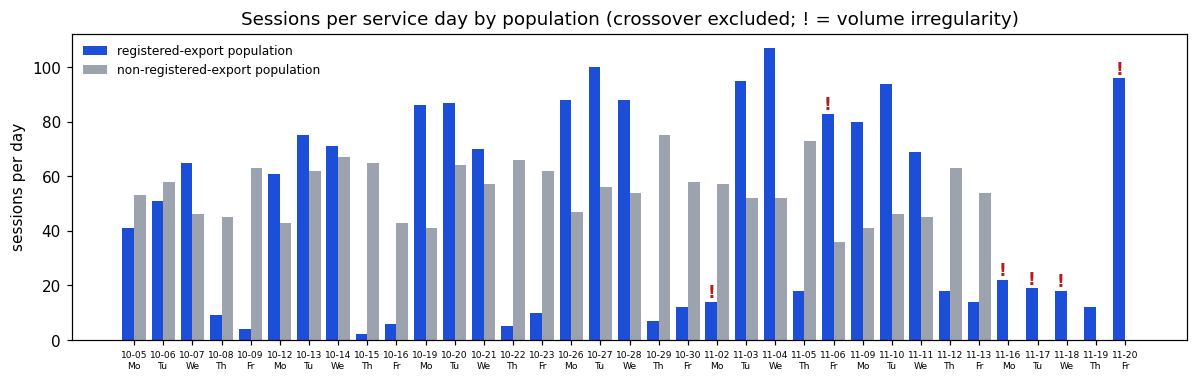

In [7]:
import numpy as np
import matplotlib.pyplot as plt
piv = day.pivot(index="service_date", columns="population", values="sessions")
wd = pd.to_datetime(piv.index).day_name()
fig, ax = plt.subplots(figsize=(11, 3.6))
x = np.arange(len(piv))
ax.bar(x - 0.2, piv["registered_export"].fillna(0), 0.4, label="registered-export population", color="#1d4ed8")
ax.bar(x + 0.2, piv["non_registered_export"].fillna(0), 0.4, label="non-registered-export population", color="#9ca3af")
irregular = ["2020-11-02", "2020-11-06", "2020-11-16", "2020-11-17", "2020-11-18", "2020-11-20"]
for i, d in enumerate(piv.index):
    if d in irregular:
        ax.annotate("!", (i - 0.2, piv["registered_export"].loc[d] + 1.5), ha="center", fontsize=11, fontweight="bold", color="#b91c1c")
ax.set_xticks(x); ax.set_xticklabels([f"{d[5:]}\n{w[:2]}" for d, w in zip(piv.index, wd)], fontsize=6)
ax.set_ylabel("sessions per day"); ax.legend(frameon=False, fontsize=8); ax.set_title("Sessions per service day by population (crossover excluded; ! = volume irregularity)")
plt.tight_layout(); plt.show()

In [8]:
print(comp.loc[comp["day"] >= "2020-11-09", ["day", "sessions", "events_per_session", "single_event_pct", "hot_pct", "median_weight"]].to_string(index=False))

       day  sessions  events_per_session  single_event_pct  hot_pct  median_weight
2020-11-09        80                4.12              2.50    95.00          490.0
2020-11-10        94                5.01              0.00    94.68          521.0
2020-11-11        69                4.80              1.45    94.20          519.0
2020-11-12        18                5.39              0.00   100.00          520.0
2020-11-13        14                5.00              0.00   100.00          637.5
2020-11-16        22                4.95              0.00    95.45          521.5
2020-11-17        19                4.63              5.26    94.74          561.0
2020-11-18        18                5.22              0.00    88.89          475.5
2020-11-19        12                4.33              8.33    91.67          597.5
2020-11-20        96                5.41              0.00    98.96          472.5


## 7. Findings expressed as validation issues
1,278 issues, no rows deleted. ERROR = identity conflicts only.

In [9]:
print(issues.groupby(["rule_id", "severity", "population"]).size().unstack(fill_value=0).to_string())

population        both  non_registered_export  registered_export
rule_id severity                                                
B02     WARN         0                      3                  3
B03     INFO         0                    413                 99
B04     WARN         0                      0                 17
B05     INFO         0                     10                212
B07     WARN         0                    470                 15
C02     INFO         0                      0                  1
        WARN         0                      0                  6
C03     WARN         0                      1                  0
I01     ERROR        0                      2                  2
I02     WARN         0                      1                  1
I06     INFO         1                      0                  0
        WARN         1                      0                  0
S03     INFO         0                      3                  4
T04     WARN         0   

## 8. KPI sensitivity **preview** (not final evidence)
M1 stays within 499-505 g and M4 is 5 in every scenario. M2 is the sensitive one. The pipeline will compute the real KPIs.

In [10]:
print(kpi[["scenario", "sessions", "M1_median_g", "M2_p90_g", "M4_median_components"]].to_string(index=False))

                                               scenario  sessions  M1_median_g  M2_p90_g  M4_median_components
      PRIMARY: registered-export, crossover quarantined      1697        499.0    1039.6                   5.0
                   exclude any session with a WARN rule      1663        500.0    1015.8                   5.0
exclude the +3h-normalised file (timezone independence)      1312        505.0     977.0                   5.0
                       exclude volume-irregularity days      1445        505.0    1066.0                   5.0
                                      exclude Nov 16-20      1530        499.5    1052.1                   5.0
                          exclude single-event sessions      1680        501.0    1044.2                   5.0
                            exclude the 2,097 g session      1696        499.0    1038.0                   5.0
       include the 2 crossover sessions (unquarantined)      1699        499.0    1042.4                   5.0


## What comes next
Thresholds and specification changes are proposed in `docs/phase2_validation_findings.md` and `docs/phase2_spec_changes.md`. Production code has not been started.